# **Quantum Algorithm Fundamentals: An Introduction to Creating and Visualizing Quantum Circuits with Qiskit**

### Speaker: Janani A, Quantum Engineer, IBM Quantum, IBM Research Bengaluru

### An Introduction to Creating and Visualizing Quantum Circuits with Qiskit

### Objectives and Takeaways

- Understanding an extremely elementary quantum computing workflow
- What is in the Qiskit Ecosystem, what are the necessary packages and how to install them
- Create a very basic quantum circuit and visualize
- Run it on simulators 
- Visualize the results and quantum states
- Creating quantum circuits for algorithmic workflows
- Inspecting circuit properties & composing quantum circuits
- Qiskit Circuit library
- Advanced circuit features
- Running quantum circuits on a fake backend

### I. Understanding an Elementary Quantum Computing Workflow

1. Create a quantum circuit
2. Select a backend to implement the quantum circuit and prepare quantum states
3. Probe into the quantum state via sampling or expectation value estimation
4. Post-process and visualize results

The most advanced version of this workflow with intermediate steps to optimize execution on real hardware is a framework called Qiskit Patterns.

### II. Qiskit Ecosystem

There are three main packages for beginners to be familiar with: 

1. Qiskit SDK: The core open-source quantum stack development kit from IBM that is used to create and compile quantum circuits for execution on real hardware. Built with a Rust-driven Python interface for users.

2. Qiskit Runtime: A service built on IBM Cloud that offers the ability to execute quantum workflows on IBM hardware and simulators all within the Qiskit software development kit.

3. Qiskit Aer: High-performance quantum computing simulators with realistic noise models. It provides interfaces to run quantum circuits with or without noise. Can be used to simulate quantum circuits locally on your laptop

In [3]:
# Installations: Use python >= 3.12. Here we are using Python 3.12.13

%pip install qiskit qiskit_ibm_runtime qiskit_aer numpy matplotlib pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [4]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.4.0


In [5]:
%pip show qiskit

Name: qiskit
Version: 2.4.0
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License-Expression: Apache-2.0
Location: c:\Users\venka\anaconda3\envs\py312_env\Lib\site-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: ibm-quantum-schemas, qiskit-aer, qiskit-ibm-runtime, samplomatic
Note: you may need to restart the kernel to use updated packages.


### III. Quantum Computing: a Brief Review

Now we have the sufficient toolkit to get started. Let us begin with a quick review of quantum computing basics.

#### 1. Classical Bits vs Qubits

| Classical Bit | Qubit |
|:---|:---|
| Can be **0** or **1** | Can be **0**, **1**, or a *superposition* of both |
| Measured value is deterministic | Measured value is **probabilistic** |
| Copied freely | Cannot be copied (no-cloning theorem) |

Qubits: A *normalized* column vector $\quad$
    $\ket{0} = \begin{pmatrix} 1\\ 0 \end{pmatrix}$
    $\ket{1} = \begin{pmatrix} 0\\ 1 \end{pmatrix}$ $\quad$ $\ket{\psi} = \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \alpha\ket{0} + \beta\ket{1}$.

    
#### 2. Quantum Gates — the building blocks

Quantum gates manipulate qubits, much like logic gates (AND, OR, NOT) manipulate classical bits. Quantum gates are unitary operators $U\ket{\psi} = \ket{\phi}$. Action of any quantum gate is a rotation on the Bloch sphere.

Here are some gates ones we'll use:

| Gate | Symbol | What it does |
|:---|:---|:---|
| **Hadamard (H)** | `H` | Puts a qubit into superposition — equal chance of 0 or 1 |
| **Pauli-X** | `X` | Flips a qubit: 0→1, 1→0 (quantum NOT gate) |
| **Pauli-Z** | `Z` | Flips the *phase* of a qubit (no visible effect on measurement alone) |
| **CNOT (CX)** | `CX` | Flips the target qubit **only if** the control qubit is 1 — creates *entanglement* |
| **Toffoli (CCX)** | `CCX` | Flips the target only if **both** controls are 1 |
| **SWAP** | `SWAP` | Exchanges the states of two qubits |

#### 3. Measurement

Qubit collapses to $\ket{0}$ or $\ket{1}$; $\quad$ measure $\ket{\psi}$ $\Rightarrow$ $\ket{0}$ with probability $|\alpha|^2$, $\ket{1}$ with probability $|\beta|^2$ $\Rightarrow$ $|\alpha|^2 + |\beta|^2 = 1$. 


### IV. Building your first quantum circuit

We can define the number of quantum and classical registers that we want. A quantum register is a qubit, and a classical register is a bit that will hold the measurement outcome of the qubit. A QuantumCircuit is an object that takes the quantum and classical registers.

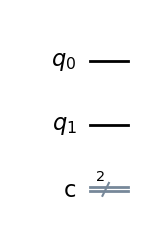

In [8]:
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit

# Create a quantum register with 2 qubits
qr = QuantumRegister(2, 'q') 
# Create a classical register with 2 bits to store measurement results
cr = ClassicalRegister(2, 'c')
# Create a quantum circuit using the quantum and classical registers
qc = QuantumCircuit(qr,cr) 
# print(qc)
qc.draw('mpl')


In [9]:
# Apply a Hadamard gate to the first qubit
qc.h(qr[0])  
# Apply a CNOT gate with the first qubit as control and the second qubit as target
qc.cx(qr[0], qr[1]) 
# Adding a barrier to separate the state preparation from measurement
qc.barrier()  
# Measure all qubits and store the results in the classical register
qc.measure(qr,cr) 
# Draw the quantum circuit 
print(qc)
#qc.draw('mpl')

     ┌───┐      ░ ┌─┐   
q_0: ┤ H ├──■───░─┤M├───
     └───┘┌─┴─┐ ░ └╥┘┌─┐
q_1: ─────┤ X ├─░──╫─┤M├
          └───┘ ░  ║ └╥┘
c: 2/══════════════╩══╩═
                   0  1 


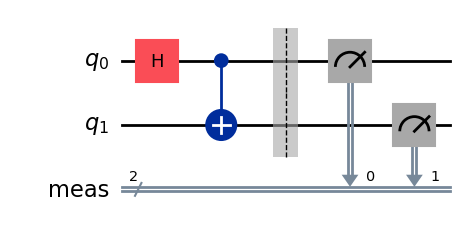

In [10]:
# Creating the same circuit more simply

qc1 = QuantumCircuit(2)
qc1.h(0)
qc1.cx(0, 1)
qc1.measure_all()
qc1.draw('mpl')

In [11]:
del qr, cr, qc, qc1

### V. Visualizing quantum state evolution in Bloch sphere

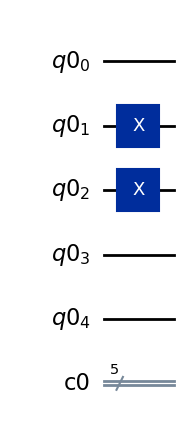

In [12]:
# Create a quantum register with 5 qubits and flip qubits 1 and 2 to the |1> state

qr = QuantumRegister(5)
cr = ClassicalRegister(5)
qc = QuantumCircuit(qr,cr)
qc.x(1)
qc.x(2)
qc.draw('mpl')

Qubits 0, 3, and 4 are initialized in |0>. In the Bloch sphere representation, this is the north pole. This is a 5-qubit system, so there should be five Bloch spheres, one for each qubit -- three of them pointing to the north pole and two to the south pole.

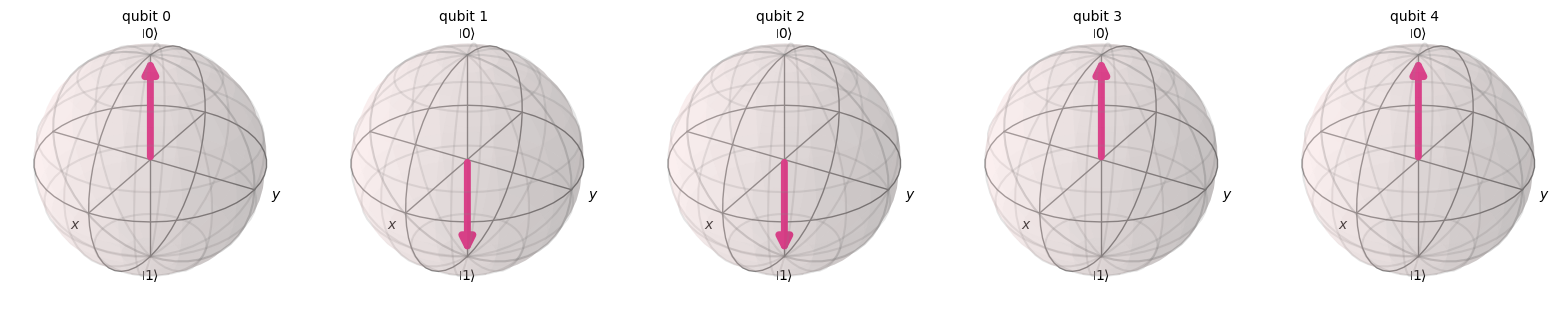

In [13]:
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(qc)


### VI. Measure the states using Simulators

Let us now measure the qubits. Since the qubits are in state |00>, the outcome should be 00 itself with probability 1.

In order to simulate the circuit, we need to define a simulator to run the circuit. We shall use Qiskit Aer for simulation and two simulators from it:

1. QASM Simulator: Noisy quantum circuit simulator within Qiskit Aer that emulates quantum hardware on classical computers and returns results in counts
2. Statevector Simulator: Designed for classical simulation of ideal quantum circuits, allowing users to calculate the exact state vector of a quantum system.

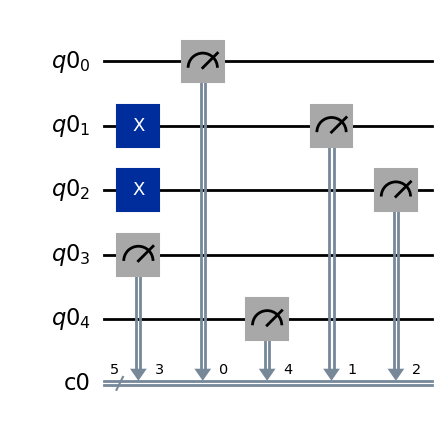

In [14]:
qc.measure(qr,cr)
qc.draw('mpl')

In [15]:
from qiskit_aer import Aer

## get counts

aer_sim = Aer.get_backend("qasm_simulator")
# qc.measure_all()
result = aer_sim.run(qc).result()
counts = result.get_counts()
print(counts)

{'00110': 1024}


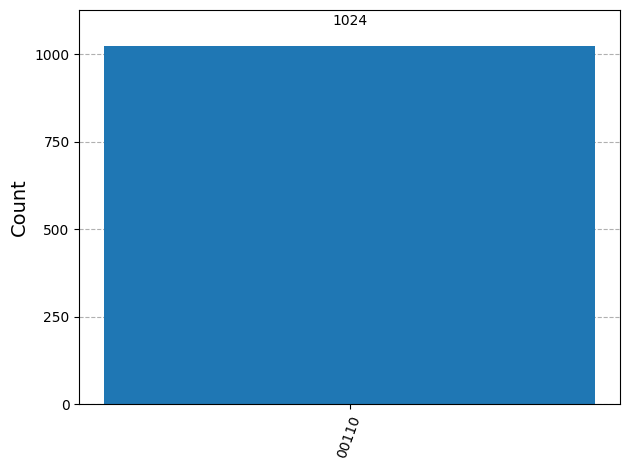

In [16]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

Let us build the statevector for a state |01> using the statevector simulator method

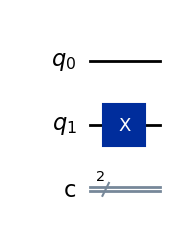

In [17]:
qc = QuantumCircuit(2,2)
qc.x(1)
qc.draw('mpl')

In [18]:
## get statevector: in this case it should return [0 0 1 0] for the two qubit state |01>

sv_sim = Aer.get_backend("statevector_simulator")
result = sv_sim.run(qc).result()
sv = result.get_statevector()
print(sv)

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


### VII. Creating a Bell State Circuit

Let's create a bell state $\ket{\Phi^+}$

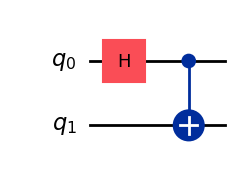

In [19]:
from math import pi
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.draw('mpl')

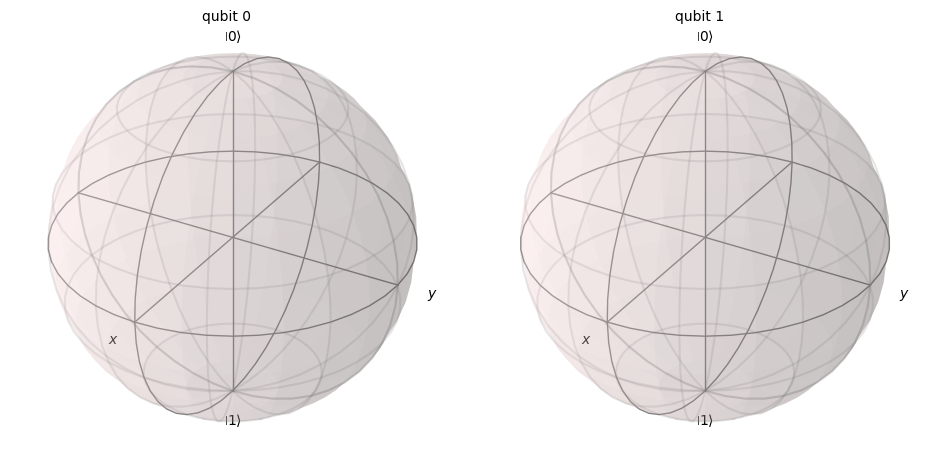

In [20]:
# visualize the state of the qubits on the bloch sphere

plot_bloch_multivector(qc)

It looks empty because the quantum states exist inside the surface of the Bloch Sphere

When we measure these two qubits, both qubits should collapse to either 0 or 1.

In [21]:
## get counts

aer_sim = Aer.get_backend("qasm_simulator")
qc.measure_all()
result = aer_sim.run(qc).result()
counts = result.get_counts()
print(counts)

{'11': 493, '00': 531}


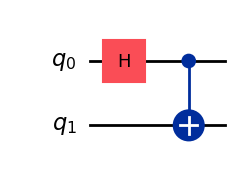

In [22]:
from math import pi
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.draw('mpl')

In [23]:
## get statevector: in this case it should return 1/sqrt(2)*[1 0 0 1] for the two qubit state 1/sqrt(2)(|00> + |11>)

sv_sim = Aer.get_backend("statevector_simulator")
result = sv_sim.run(qc).result()
sv = result.get_statevector()
print(sv)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


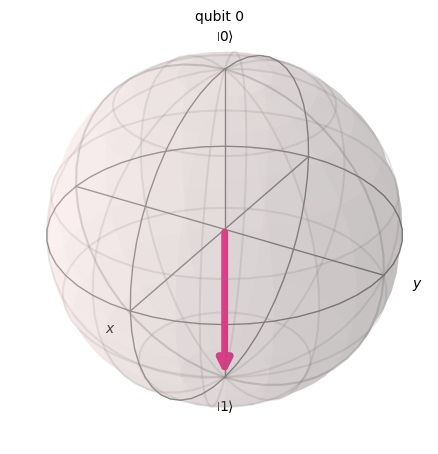

In [24]:
qc = QuantumCircuit(1)
qc.x(0)
qc.z(0)
qc.draw('mpl')

plot_bloch_multivector(qc)

In [25]:
sv_sim = Aer.get_backend("statevector_simulator")
result = sv_sim.run(qc).result()
sv = result.get_statevector()
print(sv)

Statevector([ 0.+0.j, -1.+0.j],
            dims=(2,))


### Take Home Exercise: 

Create all the bell states $\ket{\Phi^+}, \ket{\Phi^-}, \ket{\Psi^+}, \ket{\Psi^-}$ 

![alternatvie text](https://images.squarespace-cdn.com/content/v1/5d52f7bd9d7b3e0001819015/c14e81d4-a104-4364-8246-149a8875c060/2021-12-28+12_40_00-Window.png)

**Hint**: Use the above circuit and introduce X gates/ Z gates to turn 0s to 1s or introduce a negative phase.

### VIII. Creating Quantum Circuits for algorithmic workflows

Manually writing circuits is a fun learning exercise, but we are able to do simpler and more sophisticated things to create quantum circuits for algorithmic workflows. 

Let us demonstrate this by creating a GHZ state preparation circuit for three qubits, to implement GHZ state: $\frac{1}{\sqrt{2}}(\ket{000} + \ket{111})$

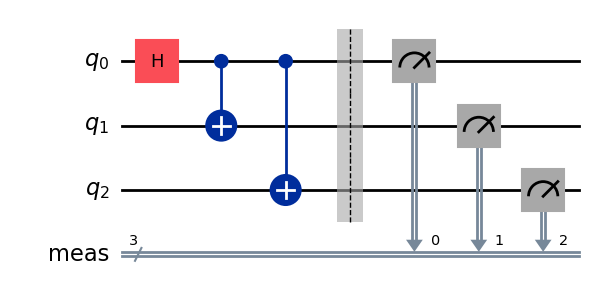

In [26]:
ghz =  QuantumCircuit(3)
ghz.h(0)
ghz.cx(0,1)
ghz.cx(0,2) # Implement your circuit here
ghz.measure_all()
ghz.draw("mpl")

In [27]:
result = aer_sim.run(ghz).result()
counts = result.get_counts()
print(counts)

{'111': 502, '000': 522}


Suppose I want to create a 6 qubit GHZ circuit?

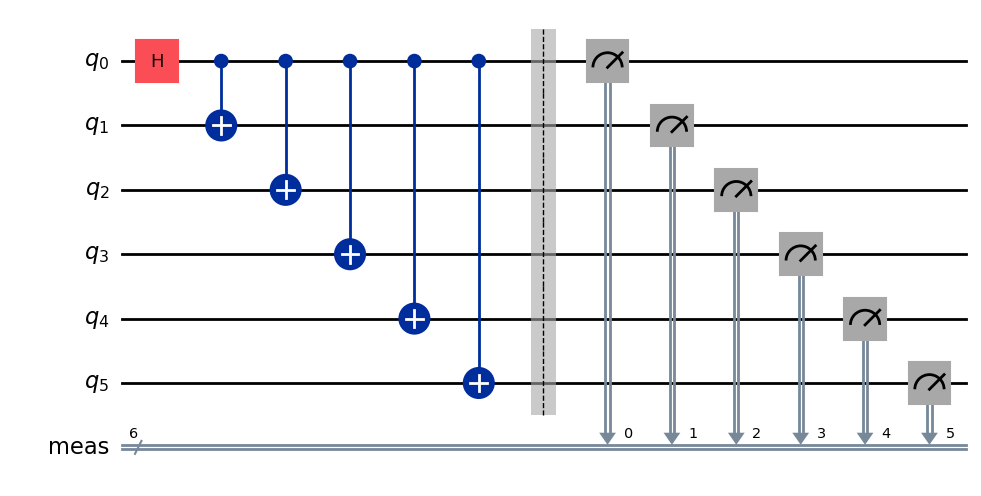

In [28]:
# Create a 6 qubit ghz state

ghz_6 = QuantumCircuit(6)
ghz_6.h(0)
for i in range(1,6):
    ghz_6.cx(0,i)
ghz_6.measure_all()
ghz_6.draw('mpl')

In [30]:
result = aer_sim.run(ghz_6).result()
counts = result.get_counts()
print(counts)

{'111111': 511, '000000': 513}


Suppose I want to create an n-qubit GHZ Circuit?

In [31]:
def n_ghz(num_qubits):
    n_ghz = QuantumCircuit(num_qubits)
    n_ghz.h(0)
    for i in range(1,num_qubits):
        n_ghz.cx(0,i)
    return n_ghz

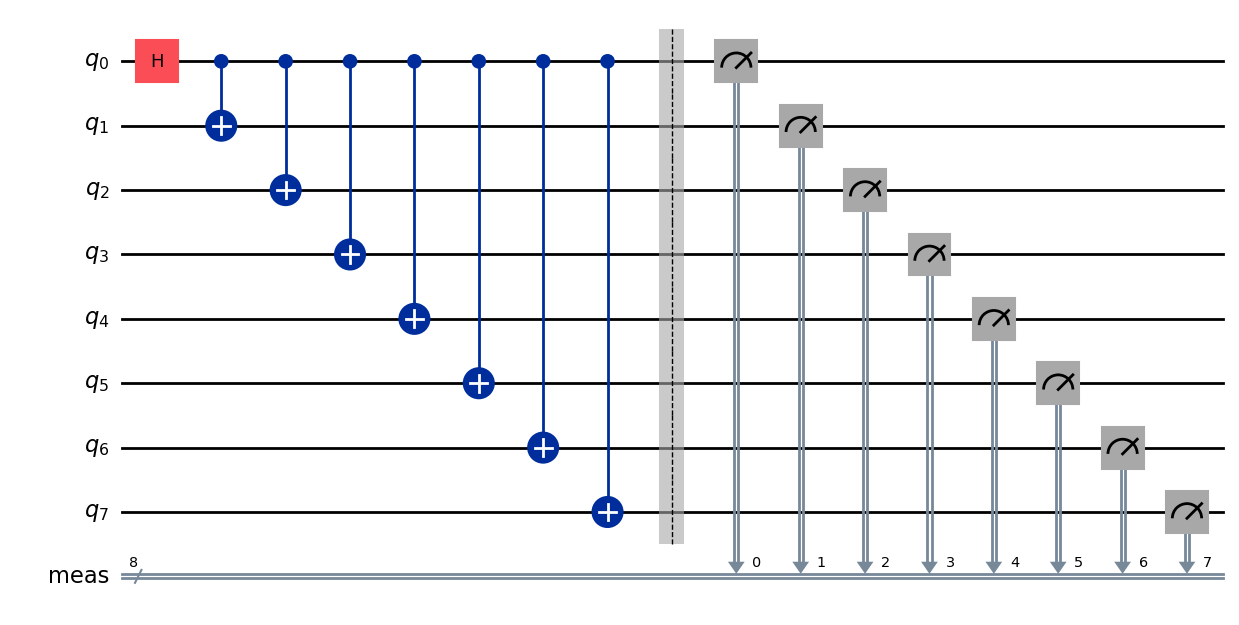

In [32]:
ghz_8 = n_ghz(8)
ghz_8.measure_all()
ghz_8.draw('mpl')

In [33]:
result = aer_sim.run(ghz_8).result()
counts = result.get_counts()
print(counts)

{'00000000': 508, '11111111': 516}


### IX.I. Inspecting Circuit Properties

Qiskit provides useful metadata about your circuits — handy for debugging and optimisation.

In [34]:
# Let's inspect our GHZ circuit
ghz = n_ghz(15)
ghz.measure_all()
print(f"Circuit depth:          {ghz.depth()}")
print(f"Total gate count:       {ghz.size()}")
print(f"Number of qubits:       {ghz.num_qubits}")
print(f"Number of clbits:       {ghz.num_clbits}")
print(f"Constituent Gates:      {dict(ghz.count_ops())}")

Circuit depth:          16
Total gate count:       30
Number of qubits:       15
Number of clbits:       15
Constituent Gates:      {'measure': 15, 'cx': 14, 'h': 1, 'barrier': 1}


### IX. II. Composing two quantum circuits

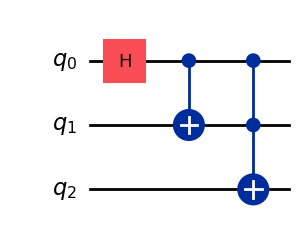

In [35]:
qc1 = QuantumCircuit(3)
qc1.h(0)
qc1.cx(0, 1)
qc1.ccx(0,1,2)
qc1.draw('mpl')

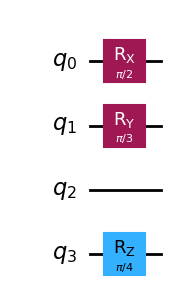

In [36]:
qc2 = QuantumCircuit(4)
qc2.rx(pi/2,0)
qc2.ry(pi/3,1)
qc2.rz(pi/4,3)
qc2.draw('mpl')

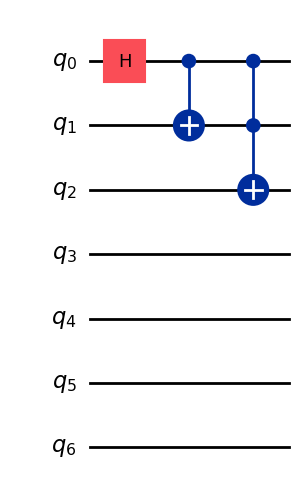

In [37]:
# Combine/compose the circuits

qc_combined = QuantumCircuit(7) # Create a new circuit with enough qubits to hold both circuits
qc_combined.compose(qc1,inplace=True)
qc_combined.draw('mpl')

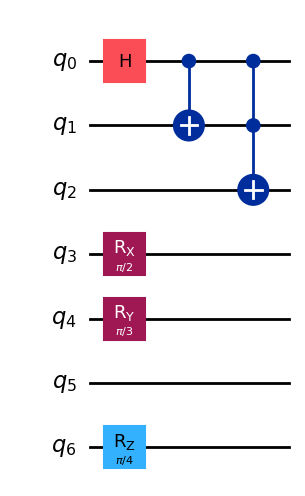

In [38]:
# qc_combined.compose(qc2,inplace=True)
qc_combined.compose(qc2, qubits=[3,4,5,6],inplace=True) 
qc_combined.draw('mpl')

### X. Qiskit Circuit Library

Suppose I want to create a QFT circuit. I can create my own circuit, but Qiskit Circuit Library contains a number of template circuits for reference that we can use: https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library

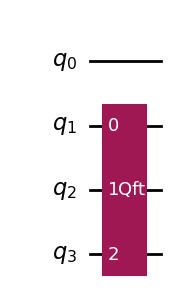

In [39]:
from qiskit.circuit.library import QFT, QFTGate

# qft = QFT(3)
# qft.draw('mpl')
qcqft = QuantumCircuit(4)
qcqft.append(QFTGate(3), qargs=[1,2,3])
qcqft.draw('mpl')

### XI. Advanced Quantum Circuit Features

Creating circuits with parameters

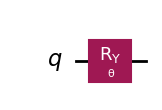

In [40]:
from qiskit.circuit import Parameter

# 1. Initialize a Parameter
theta = Parameter('θ')

# 2. Create a circuit with 1 qubit
qc = QuantumCircuit(1)

# 3. Add an RY gate using the parameter
qc.ry(theta, 0)
qc.draw('mpl')


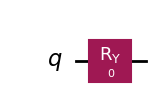

In [41]:
import numpy as np

# Define a range of 6 angles from 0 to pi
angle_range = np.linspace(0, np.pi, 6)

# Create a list of circuits, each with a different assigned angle
circuits = [qc.assign_parameters({theta: val}) for val in angle_range]

# Print the last circuit in the range
circuits[0].draw('mpl')


With each circuit, we should be able to see the quantum state evolving from |0> to |1> via rotation due to the RY gate, with thetas growing from 0 to $\pi$ in increments of $\pi/6$. Let us visualize this on the Bloch Sphere for every circuit.

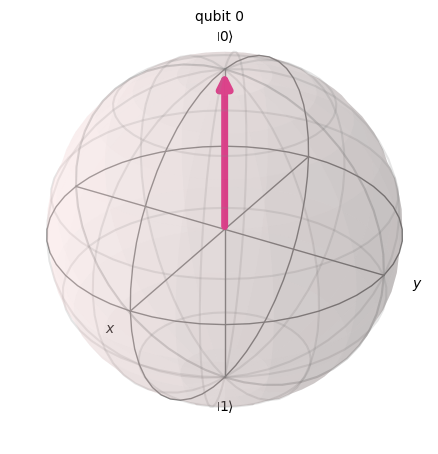

In [42]:
plot_bloch_multivector(circuits[0])

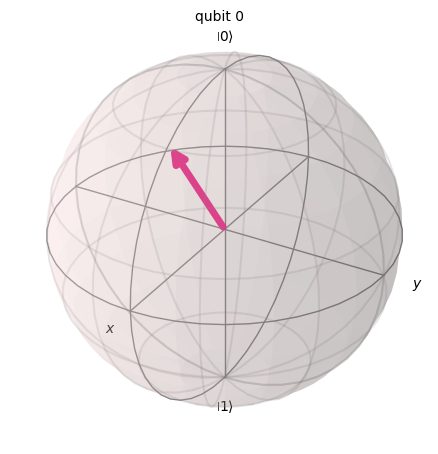

In [43]:
plot_bloch_multivector(circuits[1])

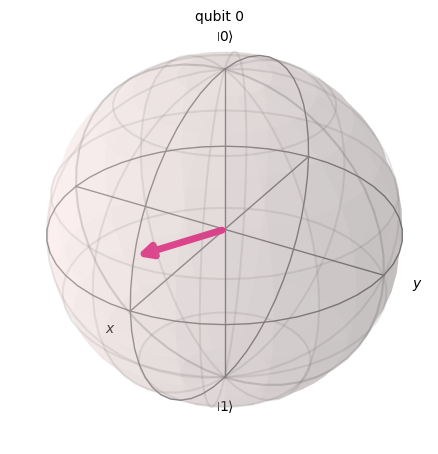

In [44]:
plot_bloch_multivector(circuits[2])

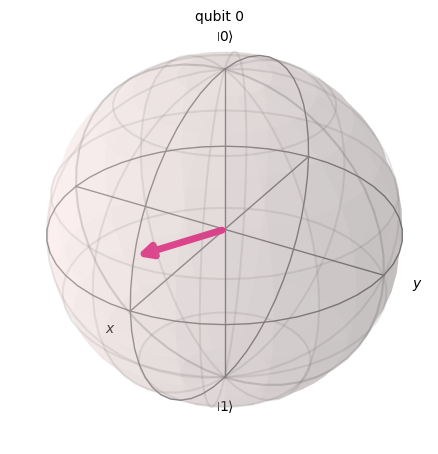

In [45]:
plot_bloch_multivector(circuits[2])

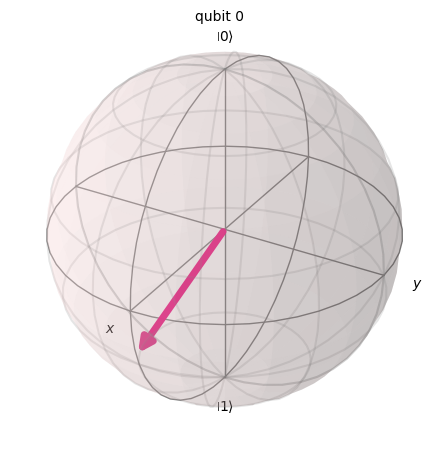

In [46]:
plot_bloch_multivector(circuits[3])

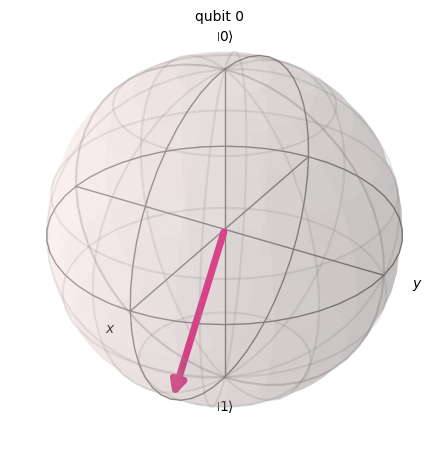

In [47]:
plot_bloch_multivector(circuits[4])

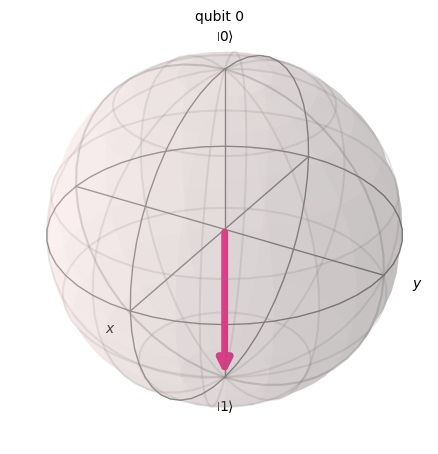

In [48]:
plot_bloch_multivector(circuits[5])

Now let us run these circuits and look at the probability amplitudes of the states from each circuit. By obtaining the |0> & |1> probability from the counts. |0> should fall from 1 to 0, whereas for |1> it grows from 0 to 1 as the angles go from 0 to $\pi$.

In [50]:
from qiskit_aer import AerSimulator
simulator = AerSimulator()
qc.measure_all()
results_0 = []
results_1 = []

for val in angle_range:
    # Assign the numerical angle to the circuit
    bound_qc = qc.assign_parameters({theta: val})
    
    # Run simulation
    job = simulator.run(bound_qc, shots=1024)
    counts = job.result().get_counts()

    # Probability of state |1> is sin^2(theta/2)
    prob_0 = counts.get('0', 0) / 1024
    results_0.append(prob_0)

    # Probability of state |1> is sin^2(theta/2)
    prob_1 = counts.get('1', 0) / 1024
    results_1.append(prob_1)

print(f"Probabilities_0: {results_0}")
print(f"Probabilities_1: {results_1}")

Probabilities_0: [1.0, 0.912109375, 0.630859375, 0.3359375, 0.0947265625, 0.0]
Probabilities_1: [0.0, 0.087890625, 0.369140625, 0.6640625, 0.9052734375, 1.0]


Let us visualize this on a histogram plot. 

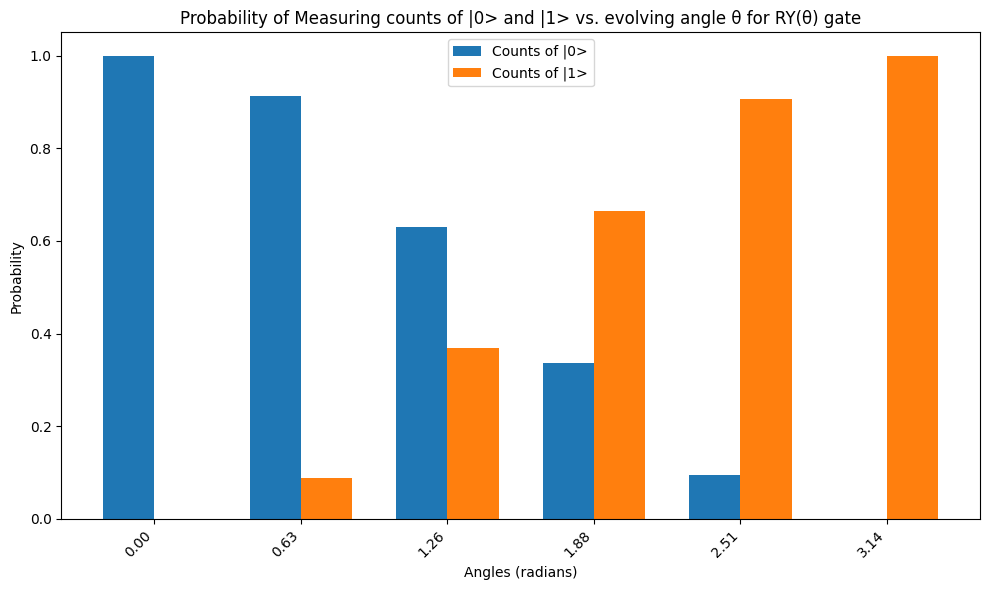

In [51]:
d1 = {str(angle_range[i]): results_0[i] for i in range(len(angle_range))}
d2 = {str(angle_range[i]): results_1[i] for i in range(len(angle_range))}
d1, d2

from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
# Round the keys to 2 decimal places for cleaner labels on the X-axis
labels = [f"{float(k):.2f}" for k in d1.keys()]
x = np.arange(len(labels))
width = 0.35  # Width of the bars
# Plotting the bars side-by-side
rects1 = ax.bar(x - width/2, list(d1.values()), width, label='Counts of |0>', color='#1f77b4')
rects2 = ax.bar(x + width/2, list(d2.values()), width, label='Counts of |1>', color='#ff7f0e')

# Labeling the chart
ax.set_ylabel('Probability')
ax.set_xlabel('Angles (radians)')
ax.set_title('Probability of Measuring counts of |0> and |1> vs. evolving angle θ for RY(θ) gate')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


### XII. Running quantum circuits on fake backends

Fake Backends (https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider) from qiskit runtime are simulators based on noise models and other properties from their real quantum device counterparts. The programmatic workflow for implementing on real backends also follows very closely the implementation on fake backend. We will see how the same 5 qubit GHZ circuit is transpiled differently (using the preset pass manager) on two different fake backends and how parameters such as circuit depth and no. of two qubit gates differ for transpilation with different optimization levels.


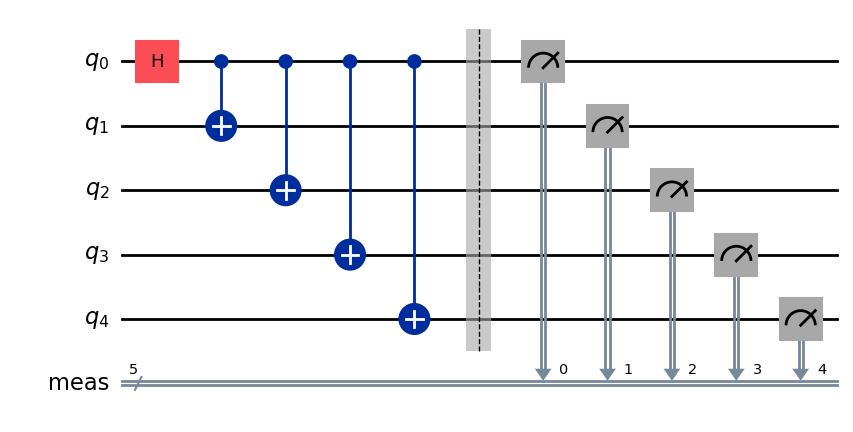

In [52]:
ghz = n_ghz(5)
ghz.measure_all()
ghz.draw('mpl')

There are different classes of IBM Quantum backends. Here, we will look at FakeBrisbane and FakeFez, which are the respective fake backends of real quantum systems ibm_brisbane and ibm_fez, which are based on IBM Eagle and IBM Heron generation quantum chips respectively. They differ in several properties, including number of qubits and supported basis gate set.

In [53]:
from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeFez

backend1 = FakeBrisbane()
backend2 = FakeFez()

print('FakeBrisbane has basis gates:', backend1.basis_gates, 'and number of qubits:', backend1.num_qubits)
print('FakeFez has basis gates:', backend2.basis_gates, 'and number of qubits:', backend2.num_qubits)

c:\Users\venka\anaconda3\envs\py312_env\Lib\site-packages\samplomatic\__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


FakeBrisbane has basis gates: ['ecr', 'id', 'rz', 'sx', 'x'] and number of qubits: 127
FakeFez has basis gates: ['cz', 'id', 'rz', 'sx', 'x'] and number of qubits: 156


The generate preset passmanager in qiskit helps create a passmanager with preset settings. The layout mapping, gate decomposition, and gate depth of the final circuit can vary depending upon the backend the circuit is compiled over and the optimization_level setting. We will analyze this by building passmanagers of different levels and examining the circuit properties of the compiled circuits.

Note: The transpiler is stochastic, meaning every attempt at transpilation may produce a different compiled circuit. Set a ```seed_transpiler``` value in ```generate_preset_pass_manager``` to get reproducible transpiled circuits

In [54]:
# passmanagers for FakeBrisbane and FakeFez with optimization levels 1 and 2 respectively

from qiskit.transpiler import generate_preset_pass_manager

#fakebrisbane
pm_b1_1 = generate_preset_pass_manager(optimization_level=1, backend=backend1)
pm_b1_2 = generate_preset_pass_manager(optimization_level=2, backend=backend1)

#fakefez
pm_b2_1 = generate_preset_pass_manager(optimization_level=1, backend=backend2)
pm_b2_2 = generate_preset_pass_manager(optimization_level=2, backend=backend2)

Depth of circuit on FakeBrisbane with optimization level 1: 38
Gate counts of circuit on FakeBrisbane with optimization level 1: {'rz': 32, 'sx': 20, 'ecr': 10, 'measure': 5, 'x': 2, 'barrier': 1}


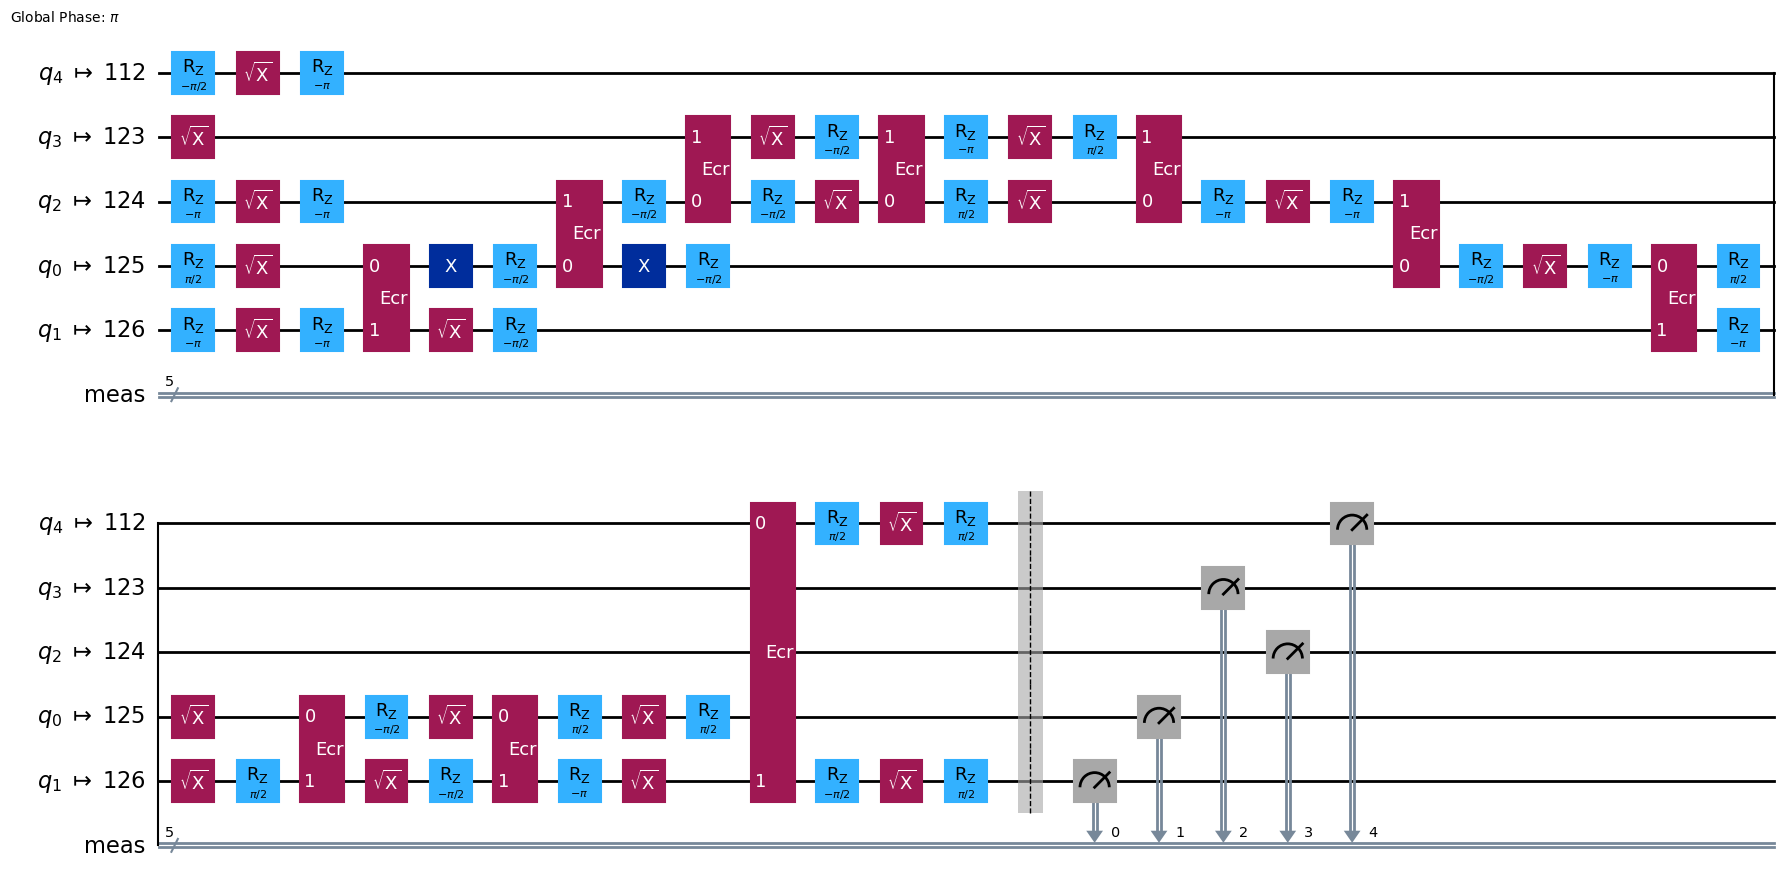

In [55]:
# transpile on FakeBrisbane with optimization level 1 and get the depth and gate counts of the transpiled circuit

ghz_b1_1 = pm_b1_1.run(ghz)
print('Depth of circuit on FakeBrisbane with optimization level 1:', ghz_b1_1.depth())
print('Gate counts of circuit on FakeBrisbane with optimization level 1:', dict(ghz_b1_1.count_ops()))
ghz_b1_1.draw('mpl')


Depth of circuit on FakeBrisbane with optimization level 2: 28
Gate counts of circuit on FakeBrisbane with optimization level 2: {'rz': 31, 'sx': 18, 'ecr': 7, 'measure': 5, 'barrier': 1}


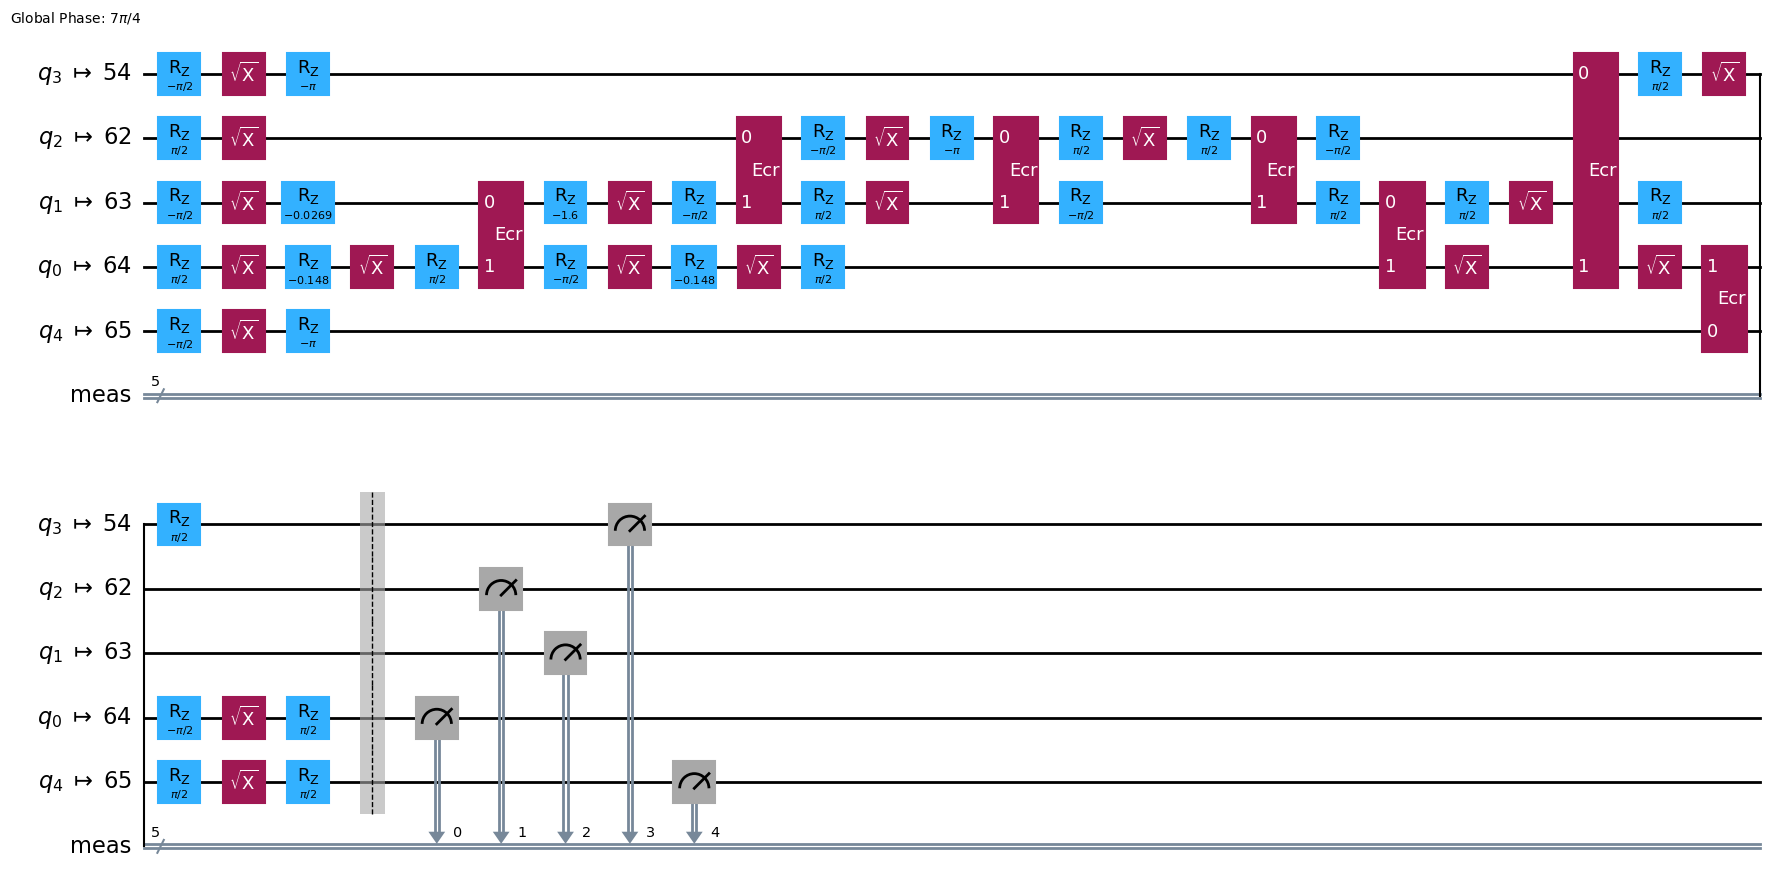

In [56]:
# transpile on FakeBrisbane with optimization level 2 and get the depth and gate counts of the transpiled circuit

ghz_b1_2 = pm_b1_2.run(ghz)
print('Depth of circuit on FakeBrisbane with optimization level 2:', ghz_b1_2.depth())
print('Gate counts of circuit on FakeBrisbane with optimization level 2:', dict(ghz_b1_2.count_ops()))
ghz_b1_2.draw('mpl')

Depth of circuit on FakeFez with optimization level 1: 19
Gate counts of circuit on FakeFez with optimization level 1: {'rz': 18, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}


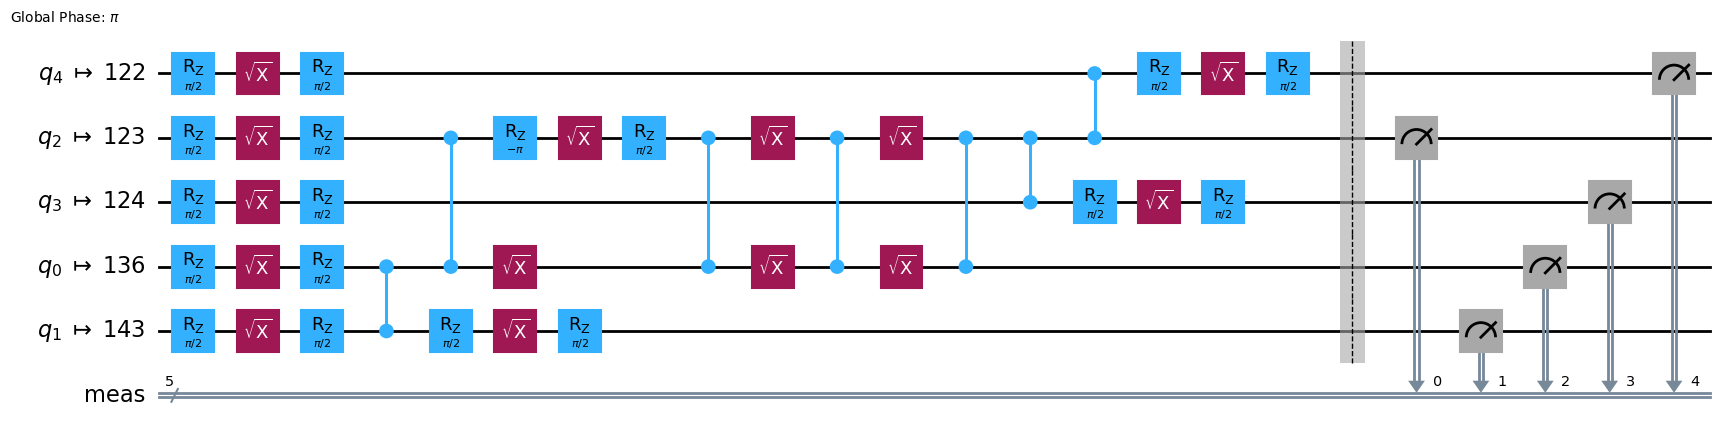

In [57]:

# transpile on FakeFez with optimization level 1 and get the depth and gate counts of the transpiled circuit

ghz_b2_1 = pm_b2_1.run(ghz)
print('Depth of circuit on FakeFez with optimization level 1:', ghz_b2_1.depth())
print('Gate counts of circuit on FakeFez with optimization level 1:', dict(ghz_b2_1.count_ops()))
ghz_b2_1.draw('mpl')


Depth of circuit on FakeFez with optimization level 2: 18
Gate counts of circuit on FakeFez with optimization level 2: {'sx': 15, 'rz': 14, 'cz': 7, 'measure': 5, 'barrier': 1}


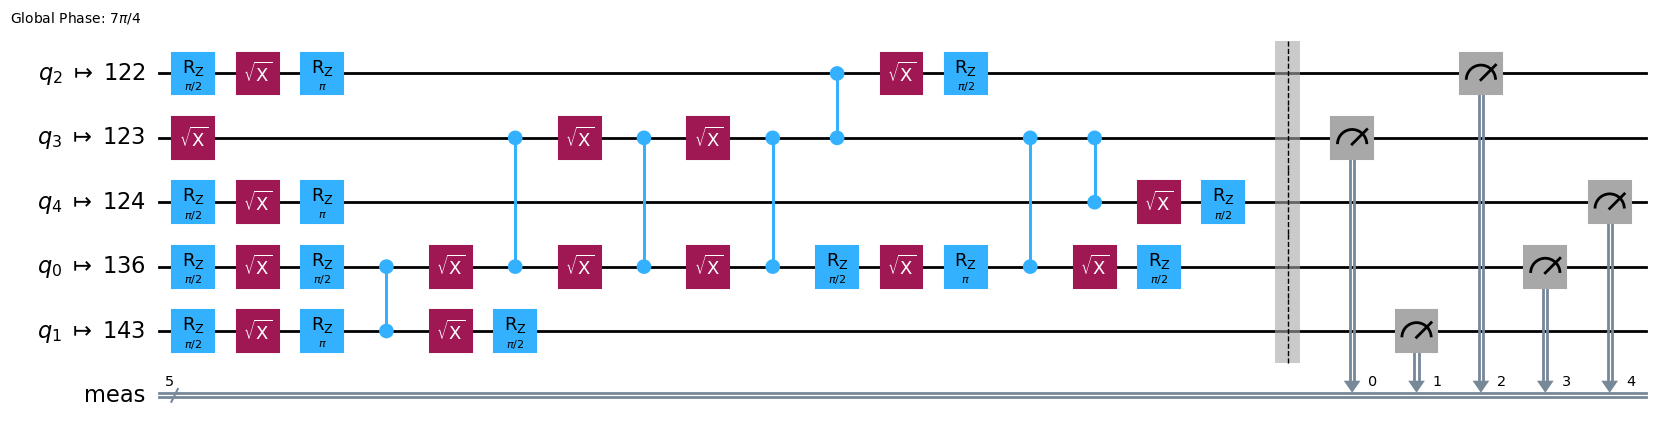

In [ ]:

# transpile on FakeFez with optimization level 2 and get the depth and gate counts of the transpiled circuit

ghz_b2_2 = pm_b2_2.run(ghz)
print('Depth of circuit on FakeFez with optimization level 2:', ghz_b2_2.depth())
print('Gate counts of circuit on FakeFez with optimization level 2:', dict(ghz_b2_2.count_ops()))
ghz_b2_2.draw('mpl')


Note the differences in the gate decompositions, number of two qubit gates, gate depth, and layout of the same 5 qubit GHZ circuit transpiled over different type of backends. 

A typical best practice for running circuits on real quantum hardware is to transpile them over a different set of transpiler_seed values and pick the circuit with the minimum depth and two qubit gate count, as shown in the example below.

In [59]:
# let use FakeFez and optimization level 2 and get the depth and gate counts of the transpiled circuit for different seeds

pm_transpiler_seeds = [generate_preset_pass_manager(optimization_level=2, backend=backend2, seed_transpiler=i) for i in range(20)]

In [60]:
transpiled_circuit_info = {}

for i, pm in enumerate(pm_transpiler_seeds):
    ghz_b2_seed = pm.run(ghz)
    transpiled_circuit_info[i] = {'circuit': ghz_b2_seed, 'depth': ghz_b2_seed.depth(), 'gate_counts': dict(ghz_b2_seed.count_ops())}
    print(f"Seed {i}")
    print(f"Circuit Depth: {transpiled_circuit_info[i]['depth']}")
    print(f"Gate counts: {transpiled_circuit_info[i]['gate_counts']}")
    print('---')


Seed 0
Circuit Depth: 19
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 1
Circuit Depth: 18
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 2
Circuit Depth: 19
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 3
Circuit Depth: 18
Gate counts: {'sx': 15, 'rz': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 4
Circuit Depth: 18
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 5
Circuit Depth: 24
Gate counts: {'sx': 20, 'rz': 14, 'cz': 10, 'measure': 5, 'barrier': 1}
---
Seed 6
Circuit Depth: 19
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 7
Circuit Depth: 16
Gate counts: {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 8
Circuit Depth: 18
Gate counts: {'sx': 15, 'rz': 14, 'cz': 7, 'measure': 5, 'barrier': 1}
---
Seed 9
Circuit Depth: 24
Gate counts: {'sx': 21, 'rz': 14, 'cz': 10, 'measure': 5, 'barrier': 1}
--

In [61]:
print('Circuit Info:',transpiled_circuit_info)

Circuit Info: {0: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE2D934FB0>, 'depth': 19, 'gate_counts': {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}}, 1: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE29B4EB40>, 'depth': 18, 'gate_counts': {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}}, 2: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE2D9F96D0>, 'depth': 19, 'gate_counts': {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}}, 3: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE2D9F82F0>, 'depth': 18, 'gate_counts': {'sx': 15, 'rz': 14, 'cz': 7, 'measure': 5, 'barrier': 1}}, 4: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE2B74BD10>, 'depth': 18, 'gate_counts': {'rz': 14, 'sx': 14, 'cz': 7, 'measure': 5, 'barrier': 1}}, 5: {'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001BE2B74

Lowest depth circuit is:
Seed: 7
Depth: 16


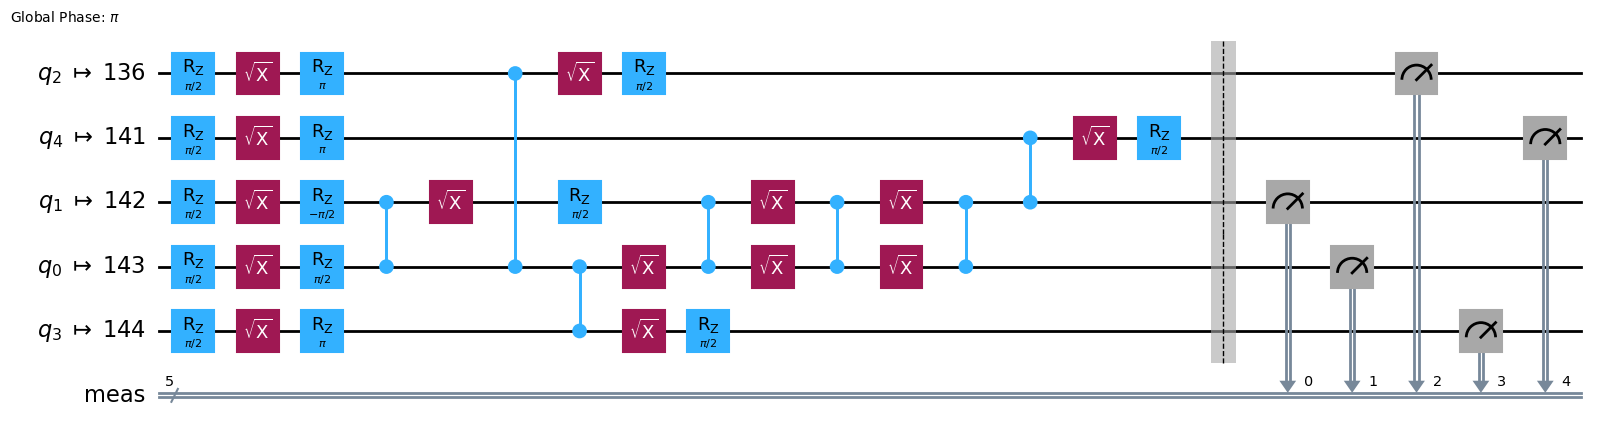

In [62]:
# find circuit with lowest depth and lowest gate count  

seed, lowest_depth_circuit = min(transpiled_circuit_info.items(), key=lambda x: x[1]['depth'])
print('Lowest depth circuit is:')
print(f"Seed: {seed}")
print(f"Depth: {lowest_depth_circuit['depth']}")
lowest_depth_circuit['circuit'].draw('mpl')
